In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

rfm = pd.read_csv("rfm_clean01.csv")

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [ ]:
# Feature Scaling (Standardization of RFM)
rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']]),
    columns=['Recency', 'Frequency', 'Monetary']
)

In [ ]:
print(rfm_scaled.head())
print(rfm_scaled.shape)

    Recency  Frequency  Monetary
0  0.973830   0.000000  0.882630
1  0.077471   0.297874  0.619999
2  0.695021   0.196884  0.540405
3  0.439947   0.000000  0.538373
4  0.964245   0.000000  0.387540
(4338, 3)


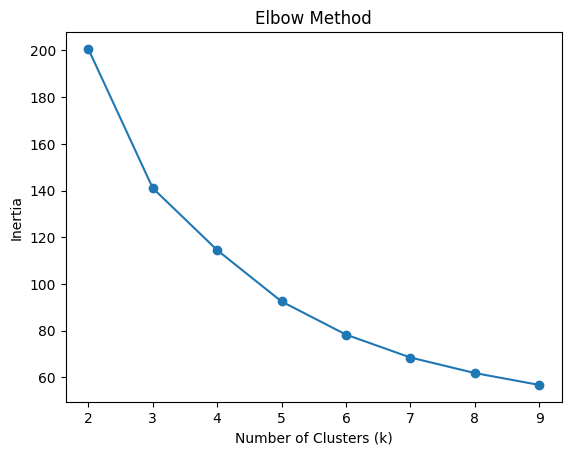

In [ ]:
# Elbow method to determine optimal k
import warnings
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled[["Recency", "Frequency", "Monetary"]])
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
# Silhouette Score Calculation
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"k={k}, score={score}")

In [ ]:
# Final KMeans Clustering with k=4
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
rfm_scaled['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm_scaled.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,0.528100,0.055797,0.397189
1,0.869695,0.044838,0.389885
2,0.571982,0.250800,0.547447
3,0.201722,0.319340,0.573076


In [ ]:
# Cluster naming based on RFM characteristics
cluster_names = {
    0: "Occasional Buyers",
    1: "At Risk",
    2: "Loyal Customers",
    3: "Champions"
}

rfm_scaled['Segment'] = rfm_scaled['Cluster'].map(cluster_names)

In [ ]:
rfm_scaled.head()

,Recency,Frequency,Monetary,Cluster,Segment
0,0.973830,0.000000,0.882630,1,At Risk
1,0.077471,0.297874,0.619999,3,Champions
2,0.695021,0.196884,0.540405,2,Loyal Customers
3,0.439947,0.000000,0.538373,0,Occasional Buyers
4,0.964245,0.000000,0.387540,1,At Risk


In [ ]:
# Final Silhouette Score Calculation
from sklearn.metrics import silhouette_score

final_score = silhouette_score(rfm_scaled.drop(['Cluster','Segment'], axis=1), rfm_scaled['Cluster'])
print("Final Silhouette Score:", final_score)

Final Silhouette Score: 0.366787588995456


In [ ]:
rfm_scaled['Segment'].value_counts()

Segment
At Risk              1498
Occasional Buyers    1141
Loyal Customers       952
Champions             747
Name: count, dtype: int64

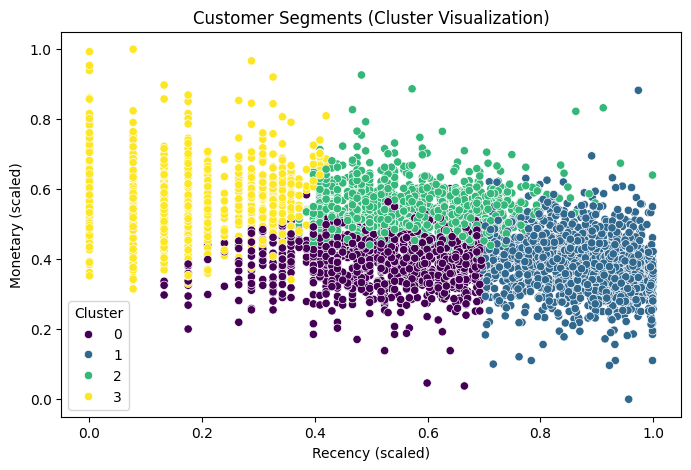

In [ ]:
# 4. Cluster Visualization

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=rfm_scaled['Recency'],
    y=rfm_scaled['Monetary'],
    hue=rfm_scaled['Cluster'],
    palette='viridis'
)

plt.title("Customer Segments (Cluster Visualization)")
plt.xlabel("Recency (scaled)")
plt.ylabel("Monetary (scaled)")
plt.legend(title="Cluster")
plt.show()

In [ ]:
from pathlib import Path
output_path = Path("rfm_with_clusters.csv")
rfm_scaled.to_csv(output_path, index=False)